# Amplitude, Power, and Complex Exponentials
### The thing Griffiths assumes you already know

**Keyboard nav:** `j/k` move cells, `Enter` edit, `Shift+Enter` run, `Esc` command mode  
**Run all:** Kernel menu -> Restart and Run All


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import *
t, omega, phi, A = symbols("t omega phi A", real=True)
print("ready")


ready


---
## S1 -- Euler Identity

```
e^(i*phi) = cos(phi) + i*sin(phi)
```
The PHYSICAL field is always the **real part**. Complex form is bookkeeping.


max |e^(i*phi) - (cos+i*sin)| = 0.0  (machine zero)


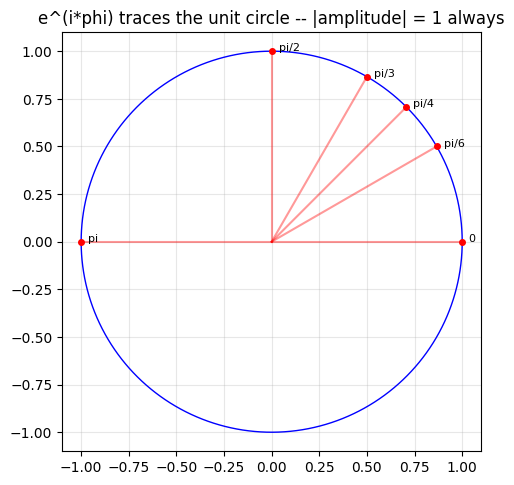

In [2]:
phi_vals = np.linspace(0, 2*np.pi, 1000)
lhs = np.exp(1j * phi_vals)
rhs = np.cos(phi_vals) + 1j*np.sin(phi_vals)
print("max |e^(i*phi) - (cos+i*sin)| =", np.max(np.abs(lhs-rhs)), " (machine zero)")

fig, ax = plt.subplots(figsize=(5,5))
ax.plot(np.cos(phi_vals), np.sin(phi_vals), "b-", lw=1)
for p, label in [(0,"0"), (np.pi/6,"pi/6"), (np.pi/4,"pi/4"),
                  (np.pi/3,"pi/3"), (np.pi/2,"pi/2"), (np.pi,"pi")]:
    ax.annotate("  "+label, (np.cos(p), np.sin(p)), fontsize=8)
    ax.plot([0,np.cos(p)],[0,np.sin(p)],"r-",alpha=0.4)
    ax.plot(np.cos(p), np.sin(p), "ro", ms=4)
ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
ax.set_title("e^(i*phi) traces the unit circle -- |amplitude| = 1 always")
plt.tight_layout(); plt.show()


---
## S2 -- Amplitude vs Power: The Factor of 2

```
E(t) = A * cos(omega*t + phi)        <- real, physical
     = Re[ A * e^(i*(omega*t+phi)) ] <- complex form

Intensity (power per area):
  I = epsilon_0 * c * <E^2>
    = epsilon_0 * c * A^2 / 2        <- /2 from <cos^2> = 1/2

THE KEY RULE:
  |E_complex|^2 = A^2          no factor of 1/2
  <E_real^2>    = A^2 / 2      1/2 from time average
  Power ~ A^2, NOT A
```


In [3]:
A_val = 3.0
omega_val = 2*np.pi
phi_val = np.pi/4
t_vals = np.linspace(0, 10, 10000)

E_real    = A_val * np.cos(omega_val*t_vals + phi_val)
E_complex = A_val * np.exp(1j*(omega_val*t_vals + phi_val))

time_avg_sq   = np.mean(E_real**2)
complex_mod_sq = np.mean(np.abs(E_complex)**2)
analytical    = A_val**2 / 2

print(f"A = {A_val}")
print(f"<E_real^2>       = {time_avg_sq:.6f}  (numerical)")
print(f"A^2/2            = {analytical:.6f}  (analytical)")
print(f"|E_complex|^2    = {complex_mod_sq:.6f}  = A^2 (no 1/2)")
print()
print("GS measures I = |E|^2 -- complex amplitude directly, no 1/2 confusion")


A = 3.0
<E_real^2>       = 4.500000  (numerical)
A^2/2            = 4.500000  (analytical)
|E_complex|^2    = 9.000000  = A^2 (no 1/2)

GS measures I = |E|^2 -- complex amplitude directly, no 1/2 confusion


---
## S3 -- Power in 3D: Poynting Vector

```
S = E x H          [W/m^2]  Poynting vector, direction = propagation
I = <|S|>          [W/m^2]  intensity

Plane wave in z:
  E = E0 * cos(kz - omega*t) * x_hat
  H = E0/eta * cos(kz - omega*t) * y_hat    eta = 377 ohm in vacuum
  <S> = E0^2 / (2*eta) * z_hat
```


In [4]:
eta0 = 377.0
A_field = 1000.0  # V/m

t_vals = np.linspace(0, 2, 10000)
omega_val = 2*np.pi
E_t = A_field * np.cos(omega_val * t_vals)
H_t = (A_field/eta0) * np.cos(omega_val * t_vals)
S_t = E_t * H_t

S_avg = np.mean(S_t)
S_anal = A_field**2 / (2 * eta0)

print(f"E amplitude:         {A_field:.1f} V/m")
print(f"<S> numerical:       {S_avg:.4f} W/m^2")
print(f"A^2/(2*eta) analyt:  {S_anal:.4f} W/m^2")
print(f"Sunlight intensity:  ~1361 W/m^2")
print(f"Sun E-field amp:     {np.sqrt(2*eta0*1361):.0f} V/m")


E amplitude:         1000.0 V/m
<S> numerical:       1326.3926 W/m^2
A^2/(2*eta) analyt:  1326.2599 W/m^2
Sunlight intensity:  ~1361 W/m^2
Sun E-field amp:     1013 V/m


---
## S4 -- SymPy: Symbolic Verification


In [5]:
x, a_s = symbols("x a", real=True, positive=True)

# Gaussian FT pair (most important in QM and GS)
f = exp(-a_s * x**2)
print("f(x) =", f)
print("FT{f} via known result: sqrt(pi/a) * exp(-k^2/(4a))")
print()

# Verify Parseval: integral |f|^2 dx = integral |F|^2 dk / (2pi)
from sympy import integrate, oo, pi as spi
parseval_lhs = integrate(f**2, (x, -oo, oo))
print("Parseval LHS (x-space):", simplify(parseval_lhs))
k_s = symbols("k", real=True)
F = sqrt(spi/a_s) * exp(-k_s**2/(4*a_s))
parseval_rhs = integrate(F**2, (k_s, -oo, oo)) / (2*spi)
print("Parseval RHS (k-space):", simplify(parseval_rhs))
print("Equal:", simplify(parseval_lhs - parseval_rhs) == 0)


f(x) = exp(-a*x**2)
FT{f} via known result: sqrt(pi/a) * exp(-k^2/(4a))



Parseval LHS (x-space): sqrt(2)*sqrt(pi)/(2*sqrt(a))
Parseval RHS (k-space): sqrt(2)*sqrt(pi)/(2*sqrt(a))
Equal: True


---
## S5 -- Practice Problems

**P1.** `E(t) = 5*cos(2*pi*3e14*t)` V/m. What is the time-averaged intensity in W/m^2?

**P2.** A laser has I = 1 MW/m^2. What is E0?

**P3.** In GS, if you double input power, does recovered phase change?

**P4.** Why does `|e^(i*phi)| = 1` always?


In [6]:
eta = 377.0

# P1
E0 = 5.0
I_P1 = E0**2 / (2*eta)
print(f"P1: I = {I_P1:.5f} W/m^2")

# P2
I_laser = 1e6
E_P2 = np.sqrt(2*eta*I_laser)
print(f"P2: E0 = {E_P2:.1f} V/m  = {E_P2/1e6:.3f} MV/m")

# P3
print("P3: phase is INVARIANT to power scale")
print("    I_new = 4*I  ->  sqrt(I_new)*exp(i*phi) = 2*sqrt(I)*exp(i*phi)")
print("    GS amplitude constraint: replaces magnitude, KEEPS phase")
print("    This is why GS works when you dont know input power")

# P4
phi_test = np.linspace(0, 100*np.pi, 100000)
mods = np.abs(np.exp(1j * phi_test))
print(f"P4: max deviation from 1: {np.max(np.abs(mods-1)):.2e}  (cos^2+sin^2=1)")


P1: I = 0.03316 W/m^2
P2: E0 = 27459.1 V/m  = 0.027 MV/m
P3: phase is INVARIANT to power scale
    I_new = 4*I  ->  sqrt(I_new)*exp(i*phi) = 2*sqrt(I)*exp(i*phi)
    GS amplitude constraint: replaces magnitude, KEEPS phase
    This is why GS works when you dont know input power
P4: max deviation from 1: 2.22e-16  (cos^2+sin^2=1)


---
## S6 -- Connection to This Project

```
Detector measures:  I(t) = |E(t)|^2      power -- phase is GONE
GS recovers:        phi(t) = angle(E(t)) phase from two measurements

Heisenberg analogy:
  Measured |E|^2  <->  position (you know WHERE power is in time)
  Lost angle(E)   <->  momentum (you lost the phase)
  I1 + I2 (two dispersions) give enough constraints to recover both

amplitude_constraint(E, I_meas):
  return sqrt(I_meas) * exp(i * angle(E))
            ^^ power        ^^ phase kept
```
